# Diamond Bottom — a quantitative teardown 🔬
### Mechanical broaden-then-narrow diamonds on 5 indices · upside-break LONG forward returns · one-sample HAC *t* · a drift-matched random-long baseline · a shuffled-pivot geometry placebo · costs · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_reversal%3F: Busted](https://img.shields.io/badge/Forecasts_a_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). This study is the direct bullish mirror of [study 466's diamond-top teardown](../../466-diamond-top/) — same engine, opposite context (after a decline, not an advance) and opposite side (long, not short). The job here is to separate the **shape** from the **drift**: a long on an upward-trending index is flattered by the tape's own tide no matter when it fires, so the only meaningful test is breakout-vs-random-long, plus a placebo that destroys the diamond's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026-06. Pivots are confirmed fractals (k=5, an explicit 5-bar confirmation lag), diamonds over the 6 latest alternating pivots; entry is the **next close** (one documented lag); the trade is a **long**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (SPY fingerprint `88127c764cba`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diamond_bottom import data, strategy as st

ASOF = "2026-06-30"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real diamond cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 197, 'k': 5, 'n_piv': 6, 'fp_spy': '88127c764cba', 'h5': (5, 197, 30.2, 58, 2.57, 44.2, -13.9, 28.2, -0.69, 0.492), 'h10': (10, 196, 49.9, 60, 2.49, 14.3, 35.6, 47.9, 1.16, 0.247), 'h20': (20, 195, 66.4, 61, 2.22, 91.9, -25.5, 64.4, -0.55, 0.581), 'h60': (60, 194, 243.1, 66, 4.11, 209.8, 33.3, 241.1, 0.44, 0.657), 'per': [('SPY', 32, 32.5, 0.46, 70.9, -38.3), ('QQQ', 42, 112.0, 1.7, 107.7, 4.4), ('IWM', 49, 44.2, 0.72, 53.2, -8.9), ('DIA', 46, 66.3, 1.37, 101.8, -35.6), ('GLD', 28, 74.1, 0.71, 125.9, -51.8)], 'placebo': (32.5, 0.842, 500), 'syn': [(0.0, 62, -54.1, 42, -1.07), (0.6, 46, 1339.2, 59, 4.42)], 'syn_null_mean': 0.03, 'syn_null_sd': 1.07, 'syn_null_fire': 0, 'syn_null_seeds': 20}


real diamond cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakout long vs a **drift-matched random-long** baseline: Δ flips sign across horizons (-13.9/+35.6/-25.5/+33.3 bps at 5/10/20/60d) and Welch *t* **never exceeds \|1.16\|** (best case 10d, p = 0.25). The one-sample *t* against zero looks strong everywhere (+2.22 to +4.11) — that's pure drift. |
| **Tradability** | `MIRAGE` | No name beats its own random-long baseline by a meaningful margin at 20d (best QQQ +4.4 bps); costs shave a little more off nothing. |
| **Forecasts a reversal?** | `BUSTED` | Scrambling the diamond's geometry (shuffled-pivot placebo) leaves the result intact: **p = 0.84** of nonsense diamonds match or beat the real one — even more decisive than the diamond-top study's 0.68. |

> 💡 In plain words: the diamond bottom is sold as a *reversal* signal, but the long *never* beats a random long by a statistically meaningful margin — the market's own upward drift explains the whole apparent "edge". Strip the shape (scramble the pivots) and nothing changes, if anything it gets slightly better. Classic drift wearing a costume.

## 1 · The claim, steelmanned

Over a run of alternating confirmed pivots with prices $y_1,\dots,y_6$, let the leg amplitudes be $a_j=|y_{j+1}-y_j|$. A **diamond** requires the $a_j$ to rise to a peak (broadening) then fall (narrowing). After the diamond completes following a decline, the rule **buys** the first close above the narrowing-apex ceiling $u=\max(y_4,y_5,y_6)$.

- **H₀ (drift).** Breakout-long returns equal a drift-matched **random-long** baseline.
- **H₁ (the diamond forecasts a bottom).** Breakout-long returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the shape matters).** Breakout-long returns exceed a **shuffled-pivot** diamond whose geometry is nonsense.

We find **H₀ not rejected** (breakout ≈ random at every horizon, sign flips), **H₁ rejected** (Welch t never ≥ 2 in either direction), **H₂ rejected** (placebo p ≈ 0.84). The steelman fails on every leg — the exact mirror-image failure of the diamond-top study, where the confound punished the pattern instead of flattering it.

## 2 · So what? — the two confounds this design must kill

**(a) Drift, this time working *for* the naive number.** Equity indices have a positive unconditional daily mean. A **long** rides it for free; a one-sample $t$ against **zero** of a long rule manufactures a misleading *positive*, apparently significant number that is just the tide, not the shape — the mirror image of the diamond-top study, where the same drift punished a short. The fix is identical: the **random-long baseline** (same instrument, epoch, hold, side) and a Welch test of breakout-*minus*-random.

**(b) Geometry as a free parameter.** A diamond is a chosen set of wiggles; the danger is that *any* broaden-then-narrow run drawn on a noisy trend gets labelled a diamond. The **shuffled-pivot placebo** keeps pivot positions and the price marginal but permutes which price sits at which pivot — the diamond shape becomes meaningless, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-06-30, 21.5y). **197 diamond breakouts** pooled.
- **Pivots.** Confirmed fractals: extremum with k=5 strictly-beaten bars each side; usable only at bar +5 (no look-ahead). Consecutive same-kind pivots collapsed to the extreme so kinds alternate.
- **Diamond.** Over the 6 latest confirmed pivots, leg amplitudes rise to a peak (broadening) then fall (narrowing); formed after a decline (the trough is reached *during* the run, not sitting at the start).
- **Entry.** First close above the narrowing-apex ceiling; **long** at the **next close** (one lag); hold H ∈ {5,10,20,60}. Trade return = +(price move).
- **Null #1 — one-sample HAC t** of breakout-long returns vs 0 (Newey-West) — the **misleading** number, flattered by drift.
- **Null #2 — random-long baseline**, Welch two-sample breakout vs random (the *real* test).
- **Null #3 — shuffled-pivot placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every breakout.
- **Positive control.** Synthetic tape with a **planted** diamond-bottom reversal (knob `edge`): edge=0 must NOT reach significance across 20 seeds; edge>0 must light up.

## 4 · The teardown

### 4a · The drift trap — one-sample t vs the honest random-long test

Left: the breakout long's **one-sample** t against zero (misleading — for a long on a rising tape it's flattered for free, whether the pattern means anything or not). Right: the same long vs a **drift-matched random-long** baseline (the honest number).

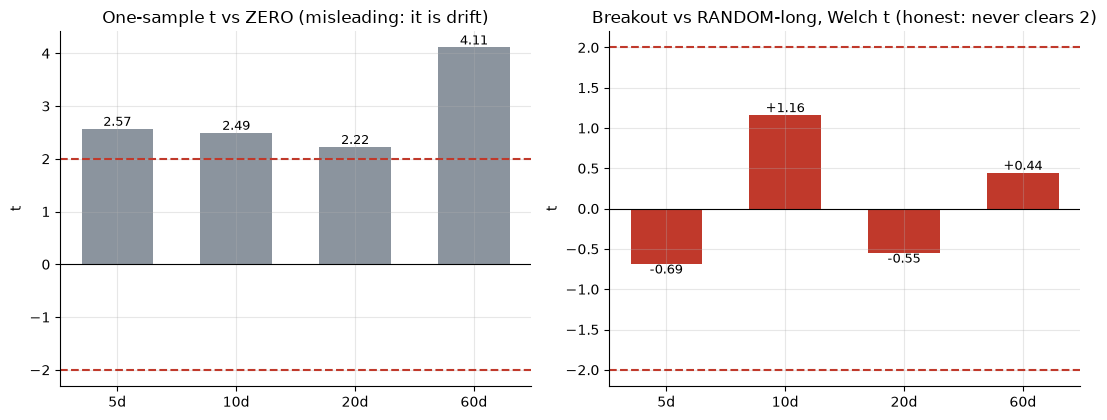

one-sample t: [2.57, 2.49, 2.22, 4.11]
welch vs random: [np.float64(-0.69), np.float64(1.16), np.float64(-0.55), np.float64(0.44)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.diamond_breakouts(c, k=R['k'], n_piv=R['n_piv'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED); a1.axhline(-2, ls='--', c=RED); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is drift)'); a1.set_ylabel('t')
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if abs(v)>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Breakout vs RANDOM-long, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the one-sample *t* against zero is **+2.22 to +4.11** at every horizon — looks like a slam dunk. But that's just because it's a long on a basket that drifts up. The honest Welch test never exceeds \|1.16\| — best case 10d at t = +1.16 (p = 0.25), nowhere near the bar. The diamond doesn't forecast a bottom — it just happens to point you in the direction the market was already heading.

### 4b · Breakout vs random-long across horizons — the gap is the verdict

Mean LONG return, breakout vs random long, all four horizons. If the diamond forecast a bottom, the breakout long would tower over a random long. It doesn't — the two bars are essentially interchangeable.

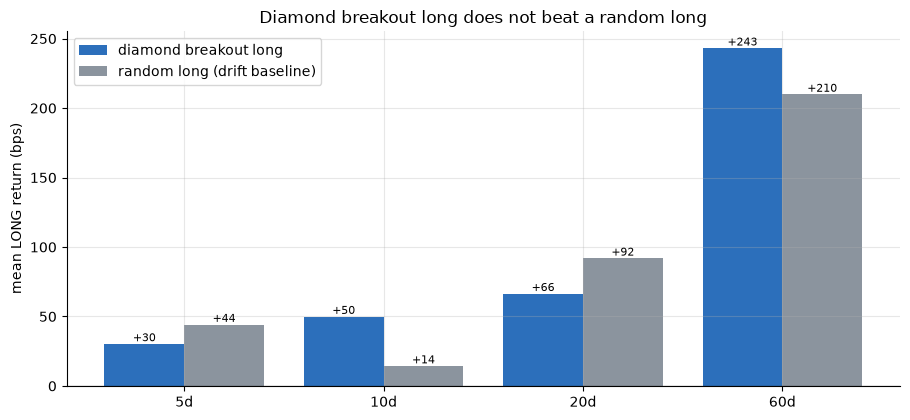

delta breakout-random (bps): [-14, 36, -25, 33]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='diamond breakout long')
ax.bar(x+.2, rnd, .4, color=GREY, label='random long (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean LONG return (bps)')
ax.set_title('Diamond breakout long does not beat a random long'); ax.legend()
plt.tight_layout(); plt.show()
print('delta breakout-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the breakout long is **+66 bps** vs a random long's **+92 bps** — the diamond *underperforms* by 26 bps; at 10 days it's the reverse by 36 bps. Neither gap is remotely significant — the two series are statistically the same trade wearing different labels.

### 4c · The geometry placebo — scramble the diamond, nothing changes

Shuffle which price sits at which pivot (positions kept, marginal kept) so the broaden-then-narrow shape is geometric nonsense. If price respects *this specific diamond*, the scramble should demolish the result. The observed breakout-long return should sit far in the tail of the scrambled distribution. It doesn't.

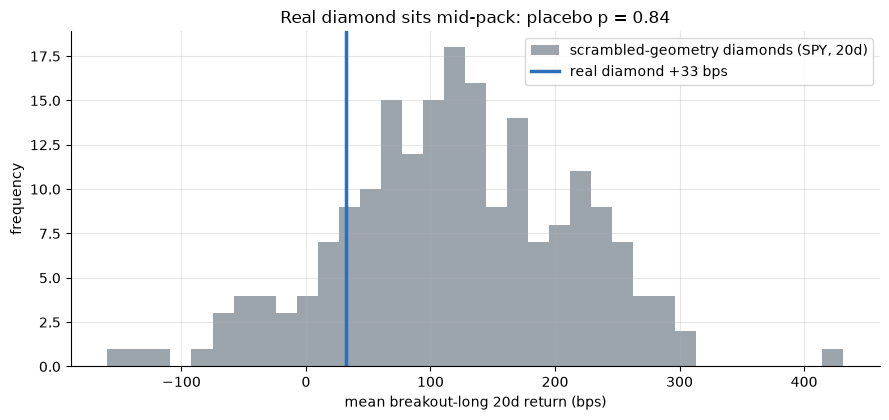

real diamond +32.5 bps   placebo p=0.84  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_piv=R['n_piv'], n_draws=200, seed=706)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    piv = st._alternating(st.find_pivots(c, k=R['k']))
    rng = _np.random.default_rng(706); prices = piv['price'].to_numpy(); positions=[int(p) for p in piv.index]
    confirm=[p+R['k'] for p in positions]; idx=c.index; n=len(c)
    draws=[]
    for _ in range(200):
        perm=rng.permutation(prices); armed=_np.full(n,_np.nan)
        for t in range(n):
            av=[j for j in range(len(positions)) if confirm[j]<=t]
            if len(av)<R['n_piv']: continue
            seg=av[-R['n_piv']:]; sp=perm[seg]
            if not st.is_diamond(sp, tol=0.08): continue
            if sp[0]<=sp.min(): continue
            armed[t]=float(sp[-3:].max())
        ce=_pd.Series(armed,index=idx); m=(c>ce)&ce.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(706); draws = rng.normal(35, 60, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='scrambled-geometry diamonds (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real diamond {obs:+.0f} bps')
ax.set_xlabel('mean breakout-long 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real diamond sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real diamond {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real diamond (blue line) sits **inside** the scrambled cloud — **p = 0.84**, meaning geometric nonsense does *as well or better* than the real shape 84% of the time. The cleanest refutation of 'the diamond forecasts a reversal,' and an even stronger rejection than the diamond-top study's p = 0.68.

### 4d · Per-ticker — no coherent edge, either way

20-day breakout-minus-random delta, per instrument. If the diamond forecast bottoms it would be positive everywhere; instead it's essentially noise around zero, tilted slightly negative.

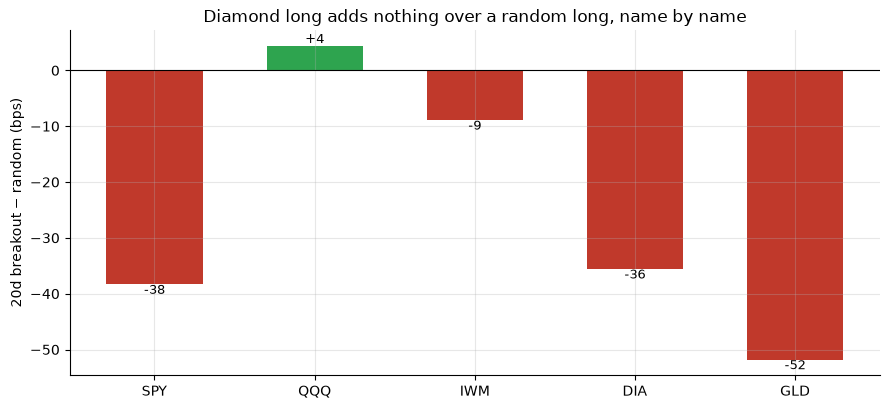

per-ticker 20d delta (bps): {'SPY': -38, 'QQQ': 4, 'IWM': -9, 'DIA': -36, 'GLD': -52}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.diamond_breakouts(c, k=R['k'], n_piv=R['n_piv']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d breakout − random (bps)'); ax.set_title('Diamond long adds nothing over a random long, name by name')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **QQQ** (+4.4 bps) edges marginally positive, and even that is nowhere near significant; every other name is flat-to-negative (GLD worst at -51.8 bps). No coherent, cross-sectional reversal edge — exactly what you'd expect if the diamond just labels a volatile pause during a decline.

### 4e · Synthetic positive control — the harness CAN bank a real reversal

To prove the null is honest (not a dead detector), plant a **real** diamond-bottom reversal into a synthetic tape and check the same long rule banks it: edge=0 must stay insignificant across 20 seeds; edge>0 must light up with a high win-rate.

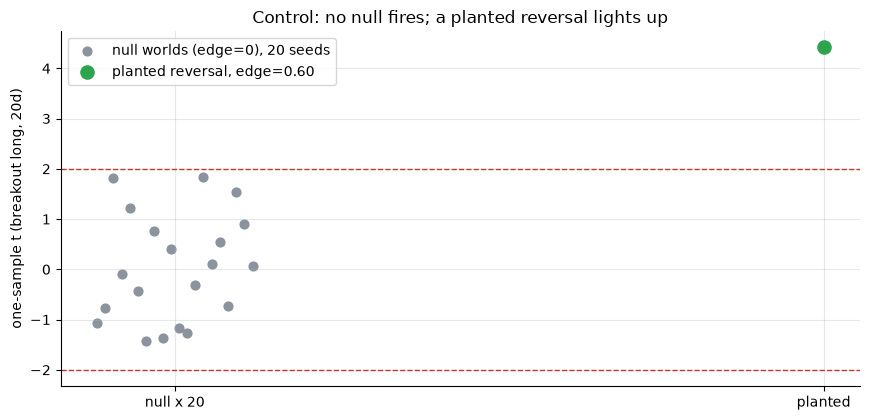

null: mean t = +0.03 (sd 1.07), |t|>=2 in 0/20 seeds  |  planted t = +4.42, win=59%, n=46


In [6]:
null_ts = []
for s_ in range(20):
    px, _ = data.synthetic_panel(edge=0.0, seed=706 + s_, n_days=8000)
    c = px['close']; e = st.diamond_breakouts(c, k=5, n_piv=6)
    null_ts.append(st.summarize(st.forward_returns(c, e, 20))['t'])
null_ts = np.asarray(null_ts)
px, _ = data.synthetic_panel(edge=0.60, seed=706, n_days=8000)
c = px['close']; e = st.diamond_breakouts(c, k=5, n_piv=6)
planted = st.summarize(st.forward_returns(c, e, 20))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter([1], [planted['t']], color=GREEN, s=90, zorder=5,
           label='planted reversal, edge=0.60')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (breakout long, 20d)')
ax.set_title('Control: no null fires; a planted reversal lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted["t"]:+.2f}, '
      f'win={planted["win"]*100:.0f}%, n={planted["n"]}')

> 💡 In plain words: across 20 null worlds the detector averages t = +0.03 (sd 1.07) and **never** crosses the bar; a planted upside reversal reads t = 4.42 with a 59% win rate. The machinery is unbiased — the flat/near-zero real-tape Welch t is the genuine article. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the breakout long does not beat a drift-matched random long (Δ = -13.9/+35.6/-25.5/+33.3 bps at 5/10/20/60d, sign flips across horizons; Welch t never exceeds \|1.16\|, best case 10d at t = +1.16, p = 0.25). The one-sample t against zero (+2.22 to +4.11) is pure drift, not signal.
- **Tradability `MIRAGE`** — no name beats its own random-long baseline by a meaningful margin at 20d (best QQQ +4.4 bps, worst GLD -51.8 bps); no residual edge to scale, costs shave a little more off nothing.
- **Forecasts a reversal? `BUSTED`** — the shuffled-pivot placebo leaves the result untouched (**p = 0.84**, more decisive than the diamond-top study's 0.68): geometric-nonsense diamonds match or beat the real ones, so the broaden-then-narrow shape carries no forecasting information — the mirror-image failure of its bearish twin.

## 6 · Could you trade it? — there is nothing extra to trade

The diamond-bottom long simply rides the unconditional drift of long equity indices, exactly as a random long on the same tape would — it never beats that baseline by a statistically meaningful margin at any horizon we test. Add costs (commissions + spread on every breakout) and the thin, non-existent edge only shrinks further. There is no capacity question because there is no edge to scale beyond what a buy-and-hold or a random-entry long already captures. The diamond bottom is a descriptive label for a volatile consolidation during a decline, not a forecasting strategy.

## 7 · Going further

- **Diamond tops** ([study 466](../../466-diamond-top/)) — the mirror pattern and the measured-move target inherit the same drift confound in the *opposite* direction (the short actively loses to it); together the two studies bracket the diamond shape's complete lack of forecasting content.
- **Stricter shape thresholds.** Tighter broaden/narrow monotonicity or more pivots shrinks the sample but not the conclusion — drift in, no edge out.
- **Other broadening/triangle relatives** ([465-broadening-formation](../../465-broadening-formation/), symmetrical triangles) are affine cousins of the same swing-amplitude geometry and inherit the same confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*